# SWE402 Student Academic Risk Advisor

This notebook prepares the UCI Student Performance dataset, explores important patterns, trains a predictive model, and prepares the model for integration with an n8n agentic workflow.

Project theme: Student Academic Risk Advisor.

Main idea: predict whether a student is high, medium, or low academic risk, then allow an n8n AI Agent to interpret the prediction and recommend a support action.

## 1. Import Libraries and Set Paths

The project uses pandas for data handling, seaborn/matplotlib for visualisation, and scikit-learn for preprocessing, training, and evaluation.

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "student_performance" / "student" / "student-por.csv"
PROCESSED_DATA_PATH = PROJECT_ROOT / "data" / "processed" / "student_por_prepared.csv"
MODEL_PATH = PROJECT_ROOT / "models" / "student_risk_model.joblib"
METADATA_PATH = PROJECT_ROOT / "models" / "student_risk_metadata.json"
FIGURE_DIR = PROJECT_ROOT / "report" / "figures"

sns.set_theme(style="whitegrid")

## 2. Load Dataset

The CSV file uses semicolons as separators, so the `sep=";"` setting is required when loading it.

In [2]:
df = pd.read_csv(RAW_DATA_PATH, sep=";")
print("Rows and columns:", df.shape)
df.head()

Rows and columns: (649, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,4,0,11,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,2,9,11,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,6,12,13,12
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,0,14,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,0,11,13,13


## 3. Dataset Structure and Quality Check

This step checks the column types, missing values, duplicate rows, and basic descriptive statistics before modelling.

In [3]:
display(df.info())
display(df.describe())
display(df.isna().sum().to_frame("missing_values"))
print("Duplicate rows:", df.duplicated().sum())

<class 'pandas.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   school      649 non-null    str  
 1   sex         649 non-null    str  
 2   age         649 non-null    int64
 3   address     649 non-null    str  
 4   famsize     649 non-null    str  
 5   Pstatus     649 non-null    str  
 6   Medu        649 non-null    int64
 7   Fedu        649 non-null    int64
 8   Mjob        649 non-null    str  
 9   Fjob        649 non-null    str  
 10  reason      649 non-null    str  
 11  guardian    649 non-null    str  
 12  traveltime  649 non-null    int64
 13  studytime   649 non-null    int64
 14  failures    649 non-null    int64
 15  schoolsup   649 non-null    str  
 16  famsup      649 non-null    str  
 17  paid        649 non-null    str  
 18  activities  649 non-null    str  
 19  nursery     649 non-null    str  
 20  higher      649 non-null    str  
 21  inte

None

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.514638,2.306626,1.568567,1.930663,0.221880,3.930663,3.180277,3.184900,1.502311,2.280431,3.536210,3.659476,11.399076,11.570108,11.906009
std,1.218138,1.134552,1.099931,0.748660,0.829510,0.593235,0.955717,1.051093,1.175766,0.924834,1.284380,1.446259,4.640759,2.745265,2.913639,3.230656
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,16.000000,2.000000,1.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,2.000000,0.000000,10.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,2.000000,11.000000,11.000000,12.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,6.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,32.000000,19.000000,19.000000,19.000000


,missing_values
school,0
sex,0
age,0
address,0
famsize,0
Pstatus,0
Medu,0
Fedu,0
Mjob,0
Fjob,0


Duplicate rows: 0


## 4. Create Risk Label

The original target column is `G3`, the final grade from 0 to 20. For this project, the grade is converted into a three-class risk label.

- High Risk: G3 < 10
- Medium Risk: 10 <= G3 <= 13
- Low Risk: G3 >= 14

In [4]:
def assign_risk_label(final_grade):
    if final_grade < 10:
        return "High Risk"
    if final_grade <= 13:
        return "Medium Risk"
    return "Low Risk"

risk_order = ["High Risk", "Medium Risk", "Low Risk"]
df["risk_label"] = df["G3"].apply(assign_risk_label)
df["risk_label"].value_counts().reindex(risk_order)

risk_label
High Risk      100
Medium Risk    355
Low Risk       194
Name: count, dtype: int64

## 5. Exploratory Data Analysis

The visualisations below show how the risk groups differ by prior grade, absences, and other numeric attributes.

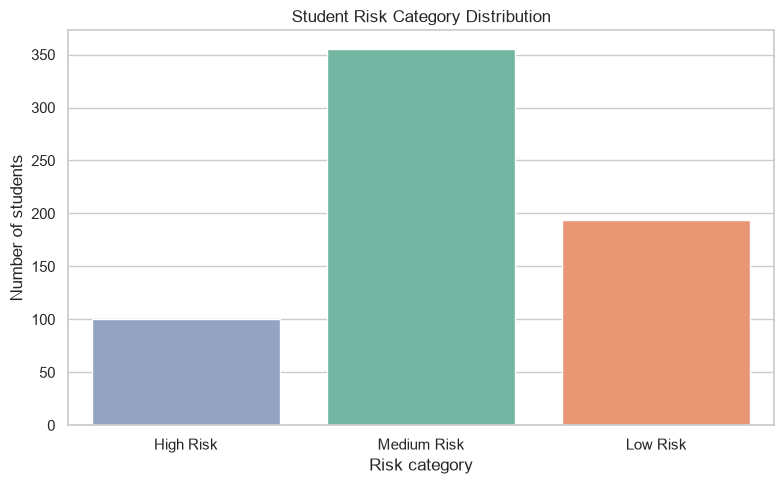

In [5]:
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="risk_label", order=risk_order, hue="risk_label", palette="Set2", legend=False)
plt.title("Student Risk Category Distribution")
plt.xlabel("Risk category")
plt.ylabel("Number of students")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "risk_category_distribution.png", dpi=160)
plt.show()

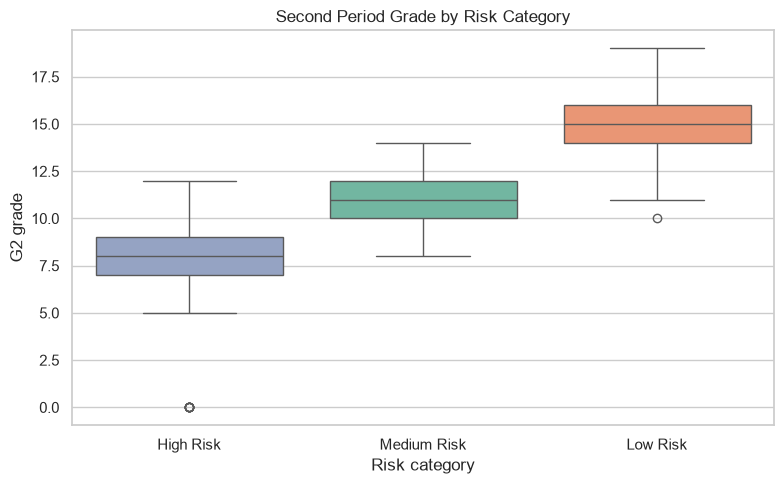

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="risk_label", y="G2", order=risk_order, hue="risk_label", palette="Set2", legend=False)
plt.title("Second Period Grade by Risk Category")
plt.xlabel("Risk category")
plt.ylabel("G2 grade")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "g2_by_risk_category.png", dpi=160)
plt.show()

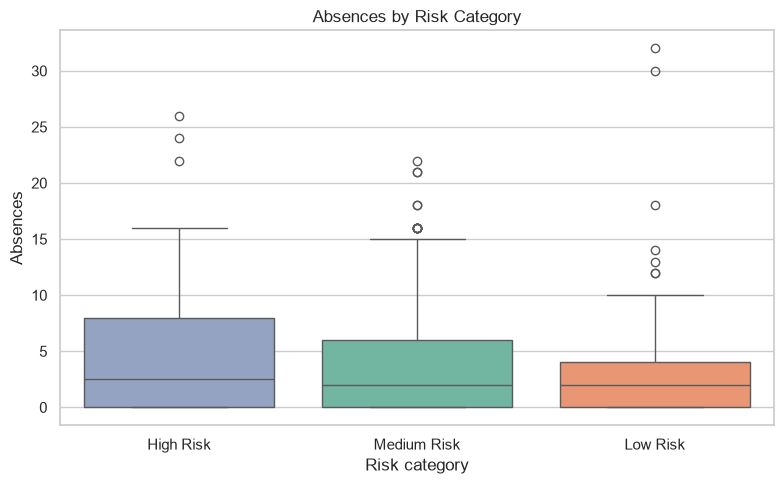

In [7]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="risk_label", y="absences", order=risk_order, hue="risk_label", palette="Set2", legend=False)
plt.title("Absences by Risk Category")
plt.xlabel("Risk category")
plt.ylabel("Absences")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "absences_by_risk_category.png", dpi=160)
plt.show()

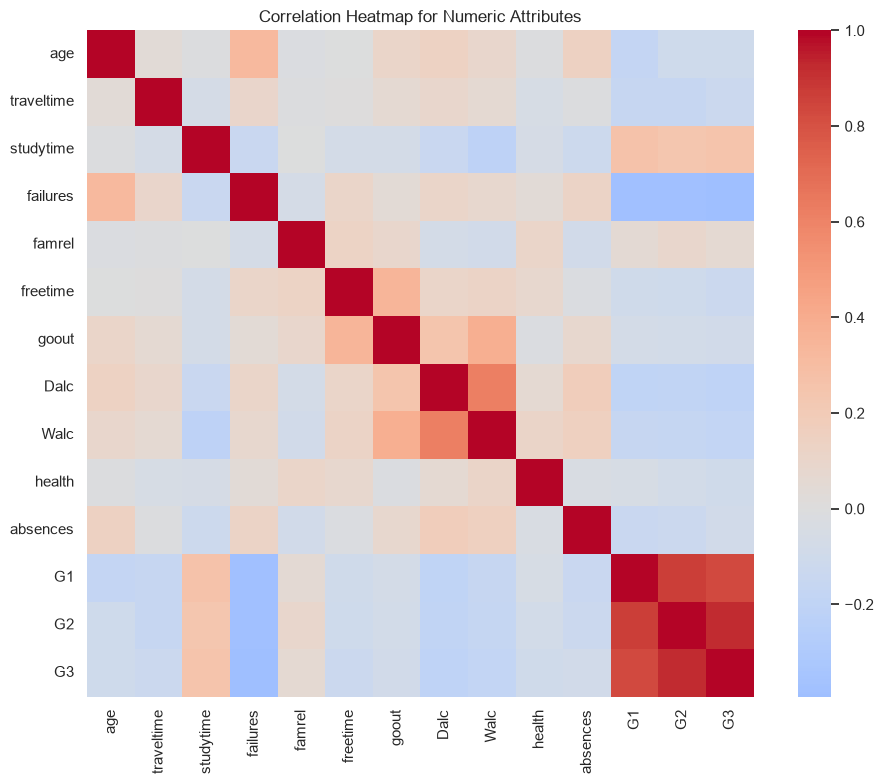

In [8]:
numeric_cols = ["age", "traveltime", "studytime", "failures", "famrel", "freetime", "goout", "Dalc", "Walc", "health", "absences", "G1", "G2", "G3"]

plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_cols].corr(), cmap="coolwarm", center=0, square=True)
plt.title("Correlation Heatmap for Numeric Attributes")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "numeric_correlation_heatmap.png", dpi=160)
plt.show()

## 6. Prepare Features and Target

The model predicts `risk_label`. The final grade `G3` is removed from the input features because it is used to create the target label.

`G1` and `G2` are kept because they are earlier period grades. This supports a practical early warning use case after the second assessment period.

In [9]:
target = "risk_label"
X = df.drop(columns=["G3", target])
y = df[target]

categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()
numeric_features = X.select_dtypes(exclude=["object", "string"]).columns.tolist()

print("Categorical features:", categorical_features)
print("Numeric features:", numeric_features)

Categorical features: ['school', 'sex', 'address', 'famsize', 'Pstatus', 'Mjob', 'Fjob', 'reason', 'guardian', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic']
Numeric features: ['age', 'Medu', 'Fedu', 'traveltime', 'studytime', 'failures', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2']


## 7. Train and Evaluate Model

A Random Forest Classifier is used because it works well for tabular classification and can model non-linear relationships between student characteristics and risk level.

In [10]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", "passthrough", numeric_features),
    ]
)

model = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    max_depth=8,
)

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model),
    ]
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

pipeline.fit(X_train, y_train)
predictions = pipeline.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, predictions), 4))
print("Weighted F1:", round(f1_score(y_test, predictions, average="weighted"), 4))
print(classification_report(y_test, predictions, labels=risk_order, zero_division=0))

Accuracy: 0.8308
Weighted F1: 0.8322
              precision    recall  f1-score   support

   High Risk       0.65      0.75      0.70        20
 Medium Risk       0.87      0.82      0.84        71
    Low Risk       0.88      0.90      0.89        39

    accuracy                           0.83       130
   macro avg       0.80      0.82      0.81       130
weighted avg       0.84      0.83      0.83       130



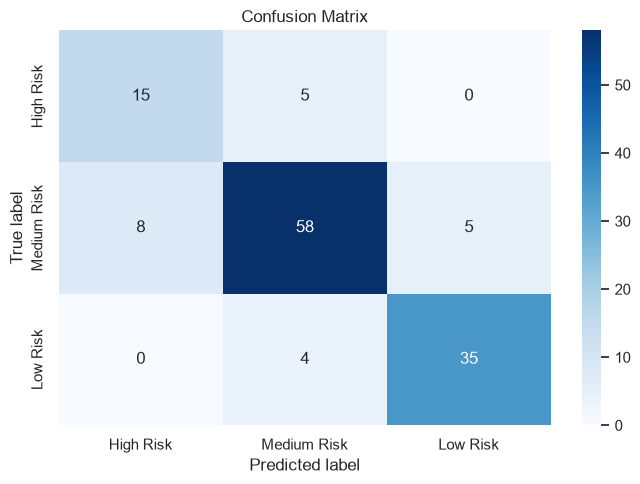

In [11]:
cm = confusion_matrix(y_test, predictions, labels=risk_order)
cm_df = pd.DataFrame(cm, index=risk_order, columns=risk_order)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()

## 8. Save Model and Metadata

The saved `joblib` model is used by the FastAPI endpoint. The metadata file stores performance results and feature information for the report.

In [12]:
PROCESSED_DATA_PATH.parent.mkdir(parents=True, exist_ok=True)
MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

df.to_csv(PROCESSED_DATA_PATH, index=False)
joblib.dump(pipeline, MODEL_PATH)

metrics = {
    "dataset": "UCI Student Performance - Portuguese language dataset",
    "row_count": int(df.shape[0]),
    "feature_count": int(X.shape[1]),
    "target_definition": {
        "High Risk": "G3 < 10",
        "Medium Risk": "10 <= G3 <= 13",
        "Low Risk": "G3 >= 14",
    },
    "class_distribution": df[target].value_counts().reindex(risk_order).fillna(0).astype(int).to_dict(),
    "accuracy": round(float(accuracy_score(y_test, predictions)), 4),
    "weighted_f1": round(float(f1_score(y_test, predictions, average="weighted")), 4),
    "features": {
        "categorical": categorical_features,
        "numeric": numeric_features,
    },
}

METADATA_PATH.write_text(json.dumps(metrics, indent=2), encoding="utf-8")
metrics

{'dataset': 'UCI Student Performance - Portuguese language dataset',
 'row_count': 649,
 'feature_count': 32,
 'target_definition': {'High Risk': 'G3 < 10',
  'Medium Risk': '10 <= G3 <= 13',
  'Low Risk': 'G3 >= 14'},
 'class_distribution': {'High Risk': 100, 'Medium Risk': 355, 'Low Risk': 194},
 'accuracy': 0.8308,
 'weighted_f1': 0.8322,
 'features': {'categorical': ['school',
   'sex',
   'address',
   'famsize',
   'Pstatus',
   'Mjob',
   'Fjob',
   'reason',
   'guardian',
   'schoolsup',
   'famsup',
   'paid',
   'activities',
   'nursery',
   'higher',
   'internet',
   'romantic'],
  'numeric': ['age',
   'Medu',
   'Fedu',
   'traveltime',
   'studytime',
   'failures',
   'famrel',
   'freetime',
   'goout',
   'Dalc',
   'Walc',
   'health',
   'absences',
   'G1',
   'G2']}}

## 9. API and n8n Integration Plan

The trained model is served by `api/main.py` using FastAPI.

Important endpoints:

- `GET /health`: checks whether the API and model artifacts are available.
- `GET /metadata`: returns model metadata.
- `POST /predict`: receives student data and returns risk level, probabilities, and a recommended action.

In n8n, the workflow should use a Webhook Trigger, HTTP Request node, AI Agent node, and an output/notification node.